In [1]:
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Normalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import numpy as np

In [51]:
df = fetch_california_housing(as_frame=True)


In [52]:
X= df.data
y = df.target


In [53]:
X.shape

(20640, 8)

In [54]:
y.shape

(20640,)

In [55]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [56]:
X.isnull().any()

,0
MedInc,False
HouseAge,False
AveRooms,False
AveBedrms,False
Population,False
AveOccup,False
Latitude,False
Longitude,False


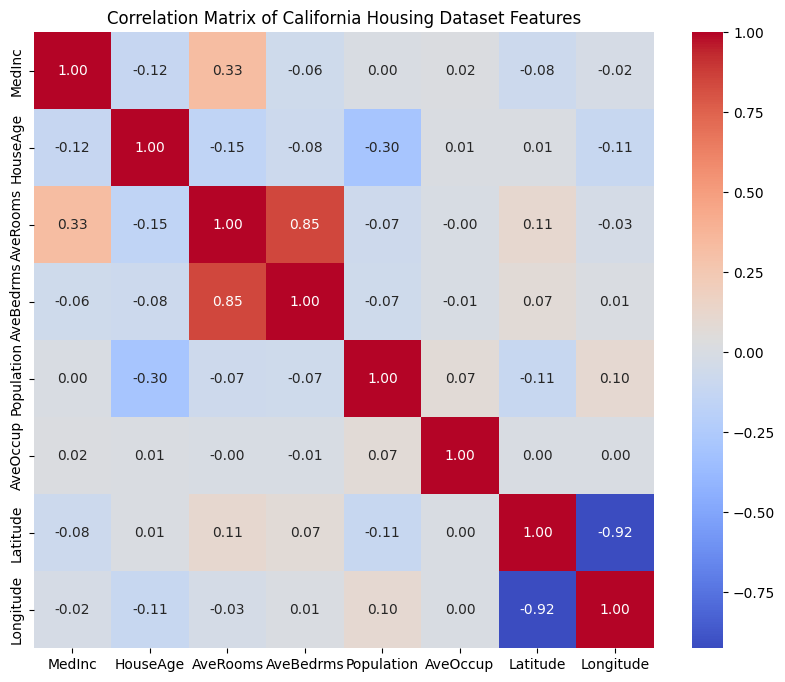

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = X.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of California Housing Dataset Features')
plt.show()

In [58]:
X_train,X_test,y_train,y_test = train_test_split( X.values.astype('float32'), y.values.astype('float32'),test_size=0.2,random_state=42)

In [59]:
norm  = tf.keras.layers.Normalization(axis=-1)
norm.adapt(X_train)

In [60]:
model = Sequential()
model.add(norm)
model.add(Dense(128,activation='relu',input_shape=(8,)))
model.add(Dropout(0.2))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer='adam',
    metrics=[ tf.keras.metrics.MeanAbsoluteError(),
        tf.keras.metrics.RootMeanSquaredError(),
        tf.keras.metrics.R2Score(), ]
)

In [62]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    mode ='min',
    patience = 20,
    verbose = 1,
    restore_best_weights = True,

)

In [63]:
his = model.fit(
    X_train,y_train,
    batch_size=64,
    epochs=200,
    validation_data=(X_test,y_test),
    callbacks=[early_stop]
)

Epoch 1/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1388.8411 - mean_absolute_error: 21.1697 - r2_score: -1078.5616 - root_mean_squared_error: 35.8232 - val_loss: 9.0778 - val_mean_absolute_error: 2.7501 - val_r2_score: -5.9274 - val_root_mean_squared_error: 3.0129
Epoch 2/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 68.1597 - mean_absolute_error: 4.8133 - r2_score: -50.2579 - root_mean_squared_error: 8.1758 - val_loss: 4.1716 - val_mean_absolute_error: 1.6871 - val_r2_score: -2.1834 - val_root_mean_squared_error: 2.0424
Epoch 3/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13.3786 - mean_absolute_error: 2.1510 - r2_score: -8.8046 - root_mean_squared_error: 3.6454 - val_loss: 2.7731 - val_mean_absolute_error: 1.2287 - val_r2_score: -1.1162 - val_root_mean_squared_error: 1.6653
Epoch 4/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.3371 - mean_absolute_error: 1.6251 - r2_score: -4.5821 - root_mean_squared_error: 2.6939 - val_loss: 2.0410 - val_mean_absolu

In [64]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Final metrics on test set
scores = model.evaluate(X_test, y_test, verbose=0)
print(dict(zip(model.metrics_names, scores)))  # names align with returned values

# Optionally compute with scikit-learn on predictions
y_pred = model.predict(X_test).ravel()
print("R2 (sklearn):", r2_score(y_test, y_pred))
print("MSE (sklearn):", mean_squared_error(y_test, y_pred))
print("MAE (sklearn):", mean_absolute_error(y_test, y_pred))

{'loss': 1.3097271919250488, 'compile_metrics': 0.9048883318901062}
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
R2 (sklearn): 0.0005205869674682617
MSE (sklearn): 1.3097268342971802
MAE (sklearn): 0.9048882126808167


# Task
Analyze the current model, identify areas for improvement, and implement changes to enhance its performance.

## Analyze current performance

### Subtask:
Review the training history and evaluation metrics to understand the model's behavior (e.g., check for overfitting or underfitting).


**Reasoning**:
Analyze the training history (`his`) to check for overfitting by plotting the training and validation loss over epochs and examine the final evaluation metrics from the `model.evaluate` output.



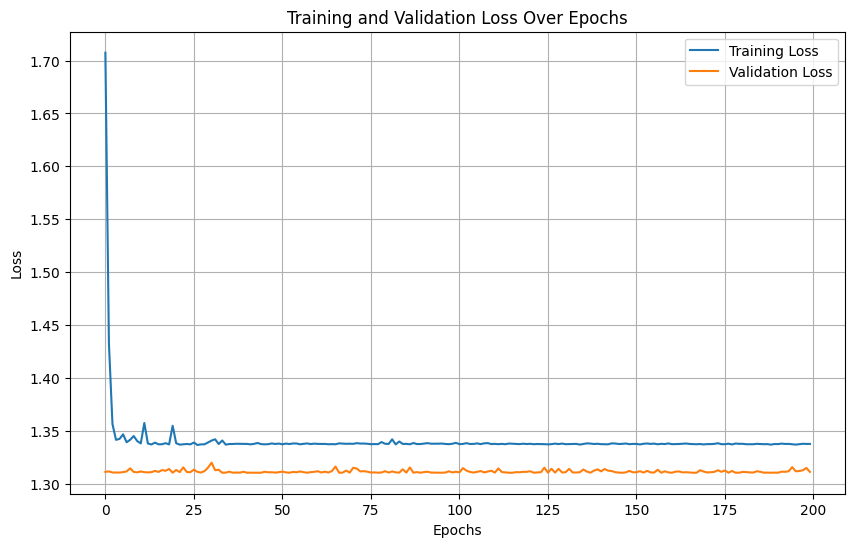

Final Model Evaluation Metrics on Test Set:
Loss: 1.3112
Mean Absolute Error: 0.9084
Root Mean Squared Error: 1.1451
R2 Score: -0.0006

Scikit-learn Metrics on Test Set:
R2 (sklearn): -0.0006
MSE (sklearn): 1.3112
MAE (sklearn): 0.9084


In [17]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(his.history['loss'], label='Training Loss')
plt.plot(his.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Review final evaluation metrics from the previous cell's output
print("Final Model Evaluation Metrics on Test Set:")
print(f"Loss: {scores[0]:.4f}")
print(f"Mean Absolute Error: {scores[1]:.4f}")
print(f"Root Mean Squared Error: {scores[2]:.4f}")
print(f"R2 Score: {scores[3]:.4f}")

# Review scikit-learn metrics
print("\nScikit-learn Metrics on Test Set:")
print(f"R2 (sklearn): {r2_score(y_test, y_pred):.4f}")
print(f"MSE (sklearn): {mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE (sklearn): {mean_absolute_error(y_test, y_pred):.4f}")

## Feature engineering

### Subtask:
Explore creating new features from existing ones that might provide more useful information to the model.


**Reasoning**:
Create new features by combining existing features and add them to the DataFrame, then display the first few rows of the modified DataFrame.



In [18]:
X_engineered = X.copy()

# Create new features
X_engineered['Rooms_per_Person'] = X_engineered['AveRooms'] / X_engineered['AveOccup']
X_engineered['Bedrms_per_Room'] = X_engineered['AveBedrms'] / X_engineered['AveRooms']
X_engineered['Population_Density'] = X_engineered['Population'] / (X_engineered['Latitude'] * X_engineered['Longitude']) # Example interaction feature

display(X_engineered.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Rooms_per_Person,Bedrms_per_Room,Population_Density
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,2.732919,0.146591,-0.069545
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,2.956685,0.155797,-0.518883
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,2.957661,0.129516,-0.107202
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,2.283154,0.184458,-0.120592
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,2.879646,0.172096,-0.122105


**Reasoning**:
Recalculate and visualize the correlation matrix for the updated DataFrame including the new features.



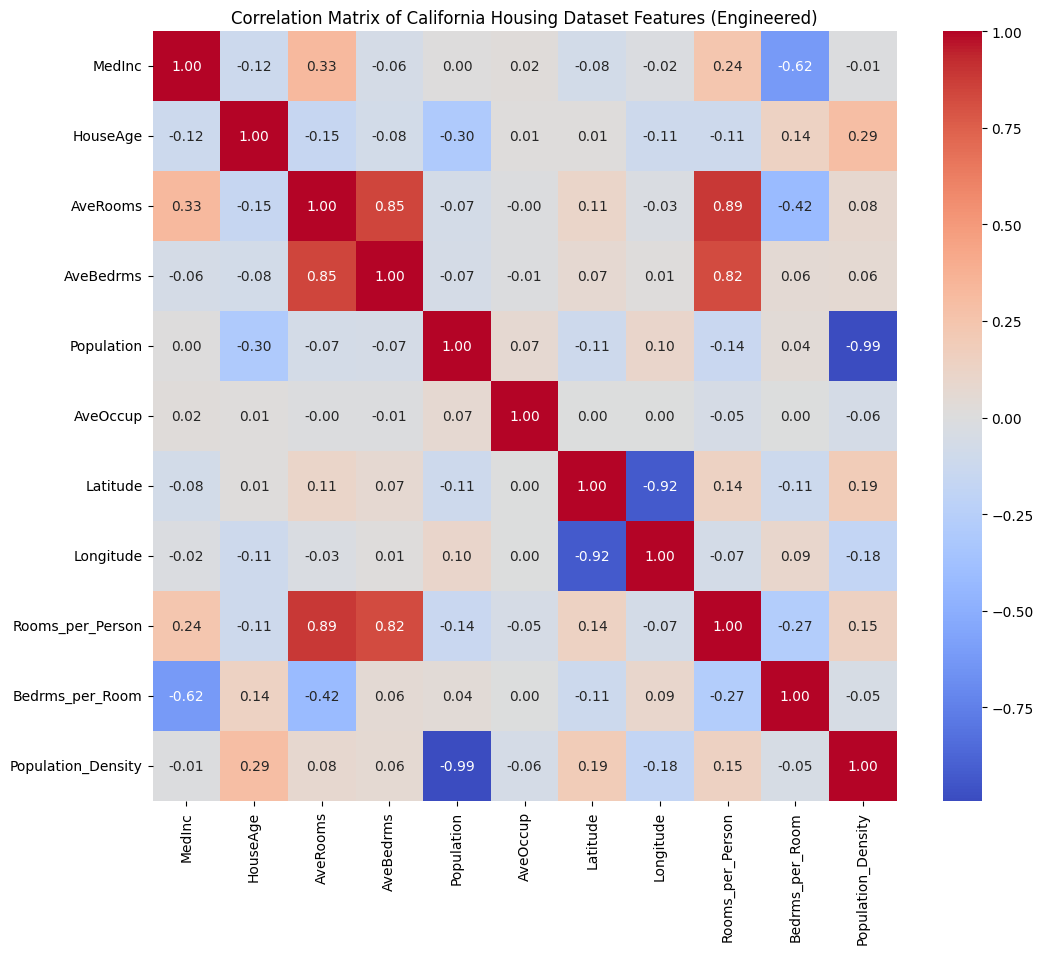

In [19]:
# Recalculate the correlation matrix
correlation_matrix_engineered = X_engineered.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_engineered, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of California Housing Dataset Features (Engineered)')
plt.show()

## Hyperparameter tuning

### Subtask:
Experiment with different hyperparameters for the model (e.g., number of layers, number of neurons per layer, activation functions, optimizer, learning rate, dropout rate, batch size, number of epochs).


**Reasoning**:
Split the engineered data, instantiate and adapt the normalization layer, build and compile the new model with the normalization layer and experimental hyperparameters, define the early stopping callback, and train the model.



In [20]:
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered.values.astype('float32'),
    y.values.astype('float32'),
    test_size=0.2,
    random_state=42
)

norm_eng = tf.keras.layers.Normalization(axis=-1)
norm_eng.adapt(X_train_eng)

model_tuned = Sequential()
model_tuned.add(norm_eng) # Add the normalization layer
model_tuned.add(Dense(256, activation='relu')) # Increased neurons
model_tuned.add(Dropout(0.3)) # Increased dropout
model_tuned.add(Dense(128, activation='relu')) # More layers
model_tuned.add(Dropout(0.3)) # More dropout
model_tuned.add(Dense(64, activation='tanh')) # Different activation
model_tuned.add(Dense(1, activation='linear'))

model_tuned.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer='adam',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(),
        tf.keras.metrics.RootMeanSquaredError(),
        tf.keras.metrics.R2Score(),
    ]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=10,
    verbose=1,
    restore_best_weights=True,
)

his_tuned = model_tuned.fit(
    X_train_eng,
    y_train_eng,
    batch_size=128, # Different batch size
    epochs=200, # Increased epochs
    validation_data=(X_test_eng, y_test_eng),
    callbacks=[early_stop]
)

Epoch 1/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.4873 - mean_absolute_error: 0.8809 - r2_score: -0.1086 - root_mean_squared_error: 1.1774 - val_loss: 0.3988 - val_mean_absolute_error: 0.4430 - val_r2_score: 0.6956 - val_root_mean_squared_error: 0.6315
Epoch 2/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4217 - mean_absolute_error: 0.4707 - r2_score: 0.6820 - root_mean_squared_error: 0.6493 - val_loss: 0.3486 - val_mean_absolute_error: 0.4166 - val_r2_score: 0.7340 - val_root_mean_squared_error: 0.5904
Epoch 3/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3758 - mean_absolute_error: 0.4414 - r2_score: 0.7139 - root_mean_squared_error: 0.6129 - val_loss: 0.3434 - val_mean_absolute_error: 0.4219 - val_r2_score: 0.7380 - val_root_mean_squared_error: 0.5860
Epoch 4/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3637 - mean_absolute_error: 0.4298 - r2_score: 0.7269 - root_mean_squared_error: 0.6030 - val_loss: 0.3311 - val_mean_absolute_error: 0.4044

In [21]:
# Final metrics on test set for the tuned model
scores_tuned = model_tuned.evaluate(X_test_eng, y_test_eng, verbose=0)
print("Final Tuned Model Evaluation Metrics on Test Set:")
print(dict(zip(model_tuned.metrics_names, scores_tuned)))

# Optionally compute with scikit-learn on predictions for the tuned model
y_pred_tuned = model_tuned.predict(X_test_eng).ravel()
print("\nTuned Model Scikit-learn Metrics on Test Set:")
print(f"R2 (sklearn): {r2_score(y_test_eng, y_pred_tuned):.4f}")
print(f"MSE (sklearn): {mean_squared_error(y_test_eng, y_pred_tuned):.4f}")
print(f"MAE (sklearn): {mean_absolute_error(y_test_eng, y_pred_tuned):.4f}")

Final Tuned Model Evaluation Metrics on Test Set:
{'loss': 0.253194123506546, 'compile_metrics': 0.3309224843978882}
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Tuned Model Scikit-learn Metrics on Test Set:
R2 (sklearn): 0.8068
MSE (sklearn): 0.2532
MAE (sklearn): 0.3309


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split data first
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and fit scaler on training data only
scaler = StandardScaler()
scaler.fit(X_train)

# Transform all datasets using the same fitted scaler
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Use transformed data for training
model.fit(X_train_scaled, y_train,
          validation_data=(X_val_scaled, y_val))
